# ML from DFT data

In [1]:
from sqlite3 import OptimizedUnicode
from unittest.mock import inplace
import matplotlib.pyplot as plt
import pandas as pd
from pygments.lexer import this
#from scipy.io._test_fortran import __test_fortran_error
from Tools.DatasetTools.DatasetOperator import Dataset
from Tools.DatasetTools.Commoms import *
from matplotlib.patches import Patch
from Tools.DatasetTools.Tools import Plotting, PlottingChulls
from Tools.DatasetTools.MLConveniences import *
from matplotlib.path import Path

/tmp/ipykernel_63471/2233343438.py:1: DeprecationWarning: 
            OptimizedUnicode is deprecated and will be removed in Python 3.12.
            Since Python 3.3 it has simply been an alias for 'str'.
        
  from sqlite3 import OptimizedUnicode
/home/mariano/.local/micromamba/envs/Test_MLFeMoTCPs/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#plt.rc('figure', figsize=(18, 8))
plt.rc('font', size=18)
plt.rc('xtick', labelsize=20)
plt.rc('ytick', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=24)
plt.rc('axes', labelsize=22)
from matplotlib.lines import Line2D

In [3]:
figwidth, figheight = plt.rcParams['figure.figsize']

# Parameters 

In [4]:
target_name = 'EF_nmhcp'

In [5]:
DS = Dataset('Fe-Mo', target_name=target_name)

In [6]:
DS.BS

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,Mag,Phase,EF_fmbcc,EF_nmhcp,EF_nmfcc
Fe_pv4Mo_sv20.C36-ABBBB.FM,bulk C36-ABBBB.FM,16.270923 A,-10.007837,204.470374 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,4,20,24,0.166667,0.833333,FM,C36,0.478663,0.478663,0.478663
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,bulk R-AAAABBBBBBB,14.436090 A,-10.020954,255.953497 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,15,38,53,0.283019,0.716981,NM,R,0.154058,0.133919,0.111544
Fe_pv2Mo_sv11.mu-BBABB.FM,bulk mu-BBABB.FM,16.007021 A,-10.117556,215.396114 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,2,11,13,0.153846,0.846154,FM,mu,0.403272,0.403272,0.403272
Fe_pv8Mo_sv22.sigma-BBBAB.NM,bulk sigma-BBBAB,14.426681 A,-10.141531,260.386848 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,8,22,30,0.266667,0.733333,NM,sigma,0.077265,0.058290,0.037208
Fe_pv2Mo_sv11.mu-BBBBA.NM,bulk mu-BBBBA,15.656633 A,-10.146330,235.078776 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,2,11,13,0.153846,0.846154,NM,mu,0.374554,0.363607,0.351444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Mo_sv1.bcc.NM,bulk bcc,15.828881 A,-10.932821,259.504388 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.016,0,1,...,1,0,1,0.000000,1.000000,NM,bcc,0.000000,0.000000,0.000000
Mo_sv8.A15.NM,bulk A15,16.079860 A,-10.837515,253.234487 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.016,0,1,...,8,0,8,0.000000,1.000000,NM,A15,0.095306,0.095306,0.095306
Mo_sv1.fcc.NM,bulk fcc,16.059116 A,-10.511038,239.489255 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.012,0,1,...,1,0,1,0.000000,1.000000,NM,fcc,0.421784,0.421784,0.421784
Mo_sv6.C15.NM,bulk C15,16.457210 A,-10.565358,234.041146 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.014,0,1,...,6,0,6,0.000000,1.000000,NM,C15,0.367463,0.367463,0.367463


# Targets

Text(0.5, 0, '$V_0$')

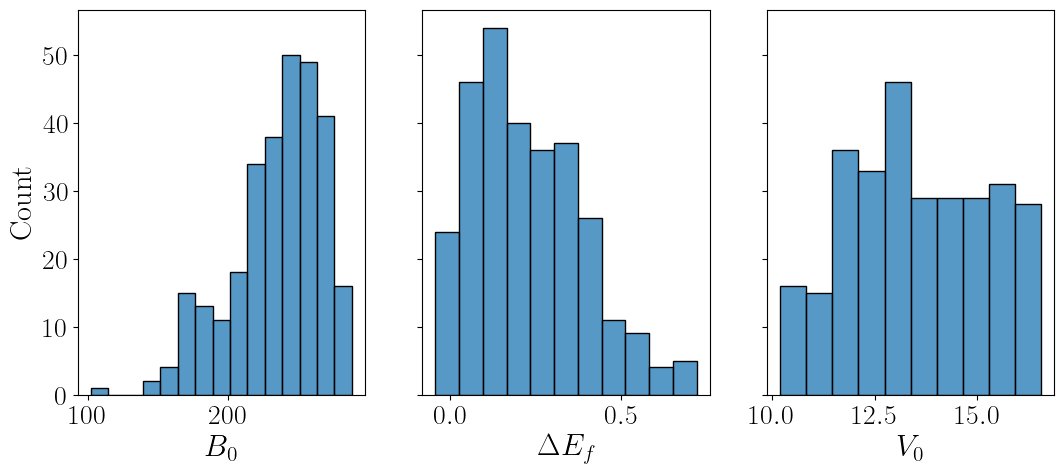

In [7]:
figwidth, figheight = plt.rcParams['figure.figsize']
fig, ax = plt.subplots(1,3, figsize=(3*figwidth*(3/5), figheight), sharey = True)
sns.histplot( DS.BS['B0'], ax= ax[0])
sns.histplot( DS.BS[target_name], ax= ax[1])
sns.histplot( DS.BS['V0'], ax= ax[2])
ax[0].set_xlabel(r'$B_0$')
ax[1].set_xlabel(r'$\Delta E_f$')
ax[2].set_xlabel(r'$V_0$')

# Machine Learning 

In [8]:
resultslocation = DS.resultslocation

## Feature sets

In [9]:
Features = DS.Features  # {name: pd.read_pickle(filename) for name, filename in DescriptorFileList.items()}

In [10]:
Features['Canonical BOP']

,Structure,Mag,U_bond_atom_list_1_0,U_bond_atom_list_1_CN12,U_bond_atom_list_1_CN13,U_bond_atom_list_1_CN14,U_bond_atom_list_1_CN15,U_bond_atom_list_1_CN16,moments_1_0,moments_1_CN12,...,Binf_0_CN16,sf_0,sf_CN12,sf_CN13,sf_CN14,sf_CN15,sf_CN16,U_bind,U_bond_atom,random
Fe_pv4Mo_sv20.C36-ABBBB.FM,3,1,-6.925199,-6.050627,0.0,0.000000,0.000000,-0.874571,0.689619,0.571110,...,0.390118,1.081732,1.156282,0.0,0.000000,0.000000,0.901327,-82.472282,-84.309469,0.637118
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,4,0,-7.069580,-2.079584,0.0,-0.750946,-0.317244,-3.921805,0.690493,0.433446,...,0.137907,1.192249,1.343511,0.0,1.139857,0.956735,0.947607,-186.101697,-189.259613,0.636232
Fe_pv2Mo_sv11.mu-BBABB.FM,9,1,-6.601047,-2.125589,0.0,-3.588088,-0.477620,-0.409750,0.647479,0.470223,...,0.166503,1.071112,1.222570,0.0,0.902495,0.748342,1.001885,-43.300202,-44.001731,0.069676
Fe_pv8Mo_sv22.sigma-BBBAB.NM,10,0,-6.958838,-1.238417,0.0,-5.296760,-0.423661,0.000000,0.658999,0.243336,...,0.000000,1.224173,1.311938,0.0,1.187306,1.155462,0.000000,-106.073592,-106.249550,0.995138
Fe_pv2Mo_sv11.mu-BBBBA.NM,9,0,-6.566157,-2.087629,0.0,-0.512510,-0.374860,-3.591159,0.647479,0.470223,...,0.166503,1.071112,1.222570,0.0,0.902495,0.748342,1.001885,-43.300202,-44.001731,0.377404
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv8Mo_sv16.C36-BAABB.NM,3,0,-7.484382,-6.463549,0.0,0.000000,0.000000,-1.020833,0.805676,0.667224,...,0.405919,1.081731,1.156281,0.0,0.000000,0.000000,0.901327,-89.290876,-91.128062,0.141327
Mo_sv1.bcc.NM,5,0,-3.130925,0.000000,0.0,-3.130925,0.000000,0.000000,0.491648,0.000000,...,0.000000,1.261308,0.000000,0.0,1.261308,0.000000,0.000000,-3.130925,-3.130925,0.889660
Mo_sv8.A15.NM,0,0,-5.978096,-3.583571,0.0,-2.394525,0.000000,0.000000,0.531115,0.136149,...,0.000000,1.195488,1.177466,0.0,1.201725,0.000000,0.000000,-25.446069,-25.453952,0.042652
Mo_sv1.fcc.NM,7,0,-2.941773,-2.941773,0.0,0.000000,0.000000,0.000000,0.471662,0.471662,...,0.000000,1.140028,1.140028,0.0,0.000000,0.000000,0.000000,-2.941774,-2.941774,0.403056


In [11]:
for featurename in Features.keys():
    print(featurename)

atomic
dataset
SOAP_specific_small
ACE
NOZERO-ACE
NOZERO_NOONE-ACE
NOZERO_NOONE_NOTWO-ACE
NOTHREE-ACE
NOTHREE-NOTWO-ACE
NOTHREE-NOTWO_NOONE-ACE
Canonical ACE
Canonical BOP
0.7dProjections 0.5OS BOP
dataset + Canonical BOP
dataset + 0.7dProjections 0.5OS BOP
atomic no CNAV
dataset no CNAV
SOAP_specific_small no CNAV
ACE no CNAV
NOZERO-ACE no CNAV
NOZERO_NOONE-ACE no CNAV
NOZERO_NOONE_NOTWO-ACE no CNAV
NOTHREE-ACE no CNAV
NOTHREE-NOTWO-ACE no CNAV
NOTHREE-NOTWO_NOONE-ACE no CNAV
Canonical ACE no CNAV
Canonical BOP no CNAV
0.7dProjections 0.5OS BOP no CNAV
dataset + Canonical BOP no CNAV
dataset + 0.7dProjections 0.5OS BOP no CNAV


## test - train splits

In [12]:
samplesplit = DS.get_samplesplit()

# Optimized models

In [13]:
from Tools.DatasetTools.MLConveniences import filter_features
import joblib
dataset='Fe-Mo'

In [14]:
models = ['Kernel Ridge', 'Random Forest','MLP']

In [15]:
modelnames=[model.replace(' ','') for model in models]

In [16]:
voting_regressor_files = {modelname: os.path.join(dataset, 'results', f'voting_regressor_{modelname}.pkl')
                         for modelname in modelnames}

In [17]:
voting_regressor_files

{'KernelRidge': 'Fe-Mo/results/voting_regressor_KernelRidge.pkl',
 'RandomForest': 'Fe-Mo/results/voting_regressor_RandomForest.pkl',
 'MLP': 'Fe-Mo/results/voting_regressor_MLP.pkl'}

In [18]:
optimal_regressors = {}
for model in modelnames:
    optimal_regressors.update(joblib.load(voting_regressor_files[model]))

In [19]:
optimal_regressors.keys()

dict_keys([('Kernel Ridge', 'atomic'), ('Kernel Ridge', 'dataset'), ('Kernel Ridge', 'Canonical ACE'), ('Kernel Ridge', 'Canonical BOP'), ('Kernel Ridge', 'ACE no CNAV'), ('Kernel Ridge', 'ACE'), ('Kernel Ridge', '0.7dProjections 0.5OS BOP'), ('Kernel Ridge', 'atomic no CNAV'), ('Kernel Ridge', 'dataset no CNAV'), ('Kernel Ridge', '0.7dProjections 0.5OS BOP no CNAV'), ('Kernel Ridge', 'SOAP_specific_small'), ('Kernel Ridge', 'SOAP_specific_small no CNAV'), ('Kernel Ridge', 'Canonical ACE no CNAV'), ('Kernel Ridge', 'Canonical BOP no CNAV'), ('Random Forest', 'atomic'), ('Random Forest', 'dataset'), ('Random Forest', 'Canonical ACE'), ('Random Forest', 'Canonical BOP'), ('Random Forest', '0.7dProjections 0.5OS BOP'), ('Random Forest', 'ACE no CNAV'), ('Random Forest', 'ACE'), ('Random Forest', 'atomic no CNAV'), ('Random Forest', 'dataset no CNAV'), ('Random Forest', '0.7dProjections 0.5OS BOP no CNAV'), ('Random Forest', 'SOAP_specific_small'), ('Random Forest', 'SOAP_specific_small no

In [20]:
trainsamples = DS.samplesplit['train']; testsamples = DS.samplesplit['test']

In [21]:
ytrain = {}
ytest = {}
ypredict = {}
for (modelname, featurename), optimalregressor in optimal_regressors.items():
    #if modelname == 'Kernel Ridge' and 'BOP' in featurename:
    print(modelname, featurename)
    optimalregressor.fit(Features[featurename].loc[DS.samplesplit['train']], DS.target[DS.samplesplit['train']])
    ytrain[(modelname, featurename)] = pd.Series(optimalregressor.predict(Features[featurename].loc[DS.samplesplit['train']]),
                      index=DS.samplesplit['train']) 
    ytest[(modelname, featurename)] = pd.Series(optimalregressor.predict(Features[featurename].loc[DS.samplesplit['test']]),
                      index=DS.samplesplit['test']) 
    ypredict[(modelname, featurename)]= pd.concat([ytrain[(modelname, featurename)], ytest[(modelname, featurename)]], axis = 0)

Kernel Ridge atomic
Kernel Ridge dataset
Kernel Ridge Canonical ACE
Kernel Ridge Canonical BOP
Kernel Ridge ACE no CNAV
Kernel Ridge ACE
Kernel Ridge 0.7dProjections 0.5OS BOP
Kernel Ridge atomic no CNAV
Kernel Ridge dataset no CNAV
Kernel Ridge 0.7dProjections 0.5OS BOP no CNAV
Kernel Ridge SOAP_specific_small
Kernel Ridge SOAP_specific_small no CNAV
Kernel Ridge Canonical ACE no CNAV
Kernel Ridge Canonical BOP no CNAV
Random Forest atomic
Random Forest dataset
Random Forest Canonical ACE
Random Forest Canonical BOP
Random Forest 0.7dProjections 0.5OS BOP
Random Forest ACE no CNAV
Random Forest ACE
Random Forest atomic no CNAV
Random Forest dataset no CNAV
Random Forest 0.7dProjections 0.5OS BOP no CNAV
Random Forest SOAP_specific_small
Random Forest SOAP_specific_small no CNAV
Random Forest Canonical ACE no CNAV
Random Forest Canonical BOP no CNAV
MLP 0.7dProjections 0.5OS BOP
MLP atomic
MLP dataset
MLP Canonical ACE
MLP ACE no CNAV
MLP ACE
MLP atomic no CNAV
MLP dataset no CNAV
MLP 

In [22]:
P = Plotting()

In [23]:
CHULL_predict = {}
bs_phase = {}

In [24]:
phases = DS.StructureNames.unique()

In [25]:
DS.StructureNames

Fe_pv4Mo_sv20.C36-ABBBB.FM           C36
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM        R
Fe_pv2Mo_sv11.mu-BBABB.FM             mu
Fe_pv8Mo_sv22.sigma-BBBAB.NM       sigma
Fe_pv2Mo_sv11.mu-BBBBA.NM             mu
                                   ...  
Fe_pv8Mo_sv16.C36-BAABB.NM           C36
Mo_sv1.bcc.NM                        bcc
Mo_sv8.A15.NM                        A15
Mo_sv1.fcc.NM                        fcc
Mo_sv6.C15.NM                        C15
Name: Phase, Length: 256, dtype: object

In [26]:
DS.BS

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,Mag,Phase,EF_fmbcc,EF_nmhcp,EF_nmfcc
Fe_pv4Mo_sv20.C36-ABBBB.FM,bulk C36-ABBBB.FM,16.270923 A,-10.007837,204.470374 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,4,20,24,0.166667,0.833333,FM,C36,0.478663,0.478663,0.478663
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,bulk R-AAAABBBBBBB,14.436090 A,-10.020954,255.953497 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,15,38,53,0.283019,0.716981,NM,R,0.154058,0.133919,0.111544
Fe_pv2Mo_sv11.mu-BBABB.FM,bulk mu-BBABB.FM,16.007021 A,-10.117556,215.396114 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,2,11,13,0.153846,0.846154,FM,mu,0.403272,0.403272,0.403272
Fe_pv8Mo_sv22.sigma-BBBAB.NM,bulk sigma-BBBAB,14.426681 A,-10.141531,260.386848 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,8,22,30,0.266667,0.733333,NM,sigma,0.077265,0.058290,0.037208
Fe_pv2Mo_sv11.mu-BBBBA.NM,bulk mu-BBBBA,15.656633 A,-10.146330,235.078776 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,2,11,13,0.153846,0.846154,NM,mu,0.374554,0.363607,0.351444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Mo_sv1.bcc.NM,bulk bcc,15.828881 A,-10.932821,259.504388 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.016,0,1,...,1,0,1,0.000000,1.000000,NM,bcc,0.000000,0.000000,0.000000
Mo_sv8.A15.NM,bulk A15,16.079860 A,-10.837515,253.234487 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.016,0,1,...,8,0,8,0.000000,1.000000,NM,A15,0.095306,0.095306,0.095306
Mo_sv1.fcc.NM,bulk fcc,16.059116 A,-10.511038,239.489255 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.012,0,1,...,1,0,1,0.000000,1.000000,NM,fcc,0.421784,0.421784,0.421784
Mo_sv6.C15.NM,bulk C15,16.457210 A,-10.565358,234.041146 GPa,murnaghan volume_relaxed,PBE-PAW,400,0.014,0,1,...,6,0,6,0.000000,1.000000,NM,C15,0.367463,0.367463,0.367463


In [27]:
bs_phase.keys()

dict_keys([])

In [28]:
for phase in phases:
    bs_phase[phase] = DS.BS.loc[DS.StructureNames.index][DS.StructureNames == phase].copy()
for ( modelname, featurename ), this_ytrain in ytrain.items():
    targetname = f'{target_name}__{featurename}__{modelname}'
    for phase in bs_phase:
        bs_phase[phase][targetname] = ypredict[(modelname, featurename)][bs_phase[phase].index]
    CHULL_predict[(modelname, featurename)] = P.get_convex_hulls(bs_phase, ['Fe', 'Mo'],getproperty=target_name)
    

In [29]:
CHULL_dft = P.get_convex_hulls(bs_phase, ['Fe', 'Mo'],getproperty=target_name)

In [30]:
#for (modelname, featurename), chull_predict in CHULL_predict.items():
#    break

In [31]:
#for phase, this_chull_predict in chull_predict.items():
#    break
#    

In [32]:
#    all_vertices_low = np.unique(np.hstack(this_chull_predict.simplices[this_chull_predict.good]))

In [33]:
#fig, ax = plt.subplots()
#ax.plot(
#    bs_phase[phase].iloc[all_vertices_low]['Fe_pv'].values,
#    bs_phase[phase].iloc[all_vertices_low][target_name].values,
#)
#sns.scatterplot(bs_phase[phase][['Fe_pv', target_name]], x='Fe_pv', y=target_name, ax = ax)

# Optimized Scores 

In [34]:
scoresfiles = {model:f'{DS.dataset}/results/{DS.dataset}_{model}_OptimalScores_{target_name}.pkl'
              for model in models}

In [35]:
scoresfiles

{'Kernel Ridge': 'Fe-Mo/results/Fe-Mo_Kernel Ridge_OptimalScores_EF_nmhcp.pkl',
 'Random Forest': 'Fe-Mo/results/Fe-Mo_Random Forest_OptimalScores_EF_nmhcp.pkl',
 'MLP': 'Fe-Mo/results/Fe-Mo_MLP_OptimalScores_EF_nmhcp.pkl'}

In [36]:
OptimizedScores = {
    model: pd.read_pickle(scoresfiles[model])
    for model in models if os.path.exists(scoresfiles[model]) 
}

In [37]:
OptimizedScores['Kernel Ridge'].sort_values(by='test')

test     train  orig_len
Kernel Ridge ACE                                0.026328  0.005503      1803
             ACE no CNAV                        0.026340  0.007254       303
             0.7dProjections 0.5OS BOP          0.028210  0.007288       513
             0.7dProjections 0.5OS BOP no CNAV  0.037149  0.019532        88
             SOAP_specific_small                0.049137  0.025368       419
             dataset                            0.053785  0.057144        32
             SOAP_specific_small no CNAV        0.081785  0.057881       130
             dataset no CNAV                    0.105371  0.069996        17
             Canonical BOP                      0.107618  0.077886       405
             Canonical BOP no CNAV              0.113719  0.086909        70
             Canonical ACE                      0.136919  0.121803       417
             Canonical ACE no CNAV              0.137721  0.123381        72
             atomic no CNAV                     0.167241  0.150194       135
             atomic                             0.167475  0.150255       135

In [38]:
newtables = []
for model, table in OptimizedScores.items():
    newtable = table.droplevel(0)
    newtable.columns = pd.MultiIndex.from_tuples( [(model, case) for case in newtable.columns])
    newtables.append(newtable)

In [39]:
fulltable = pd.concat(newtables, axis = 1)

In [40]:
fulltable.sort_values(by=('Kernel Ridge', 'test'), inplace=True)

In [41]:
fulltable

Kernel Ridge                      
                                          test     train orig_len   
ACE                                   0.026328  0.005503     1803  \
ACE no CNAV                           0.026340  0.007254      303   
0.7dProjections 0.5OS BOP             0.028210  0.007288      513   
0.7dProjections 0.5OS BOP no CNAV     0.037149  0.019532       88   
SOAP_specific_small                   0.049137  0.025368      419   
dataset                               0.053785  0.057144       32   
SOAP_specific_small no CNAV           0.081785  0.057881      130   
dataset no CNAV                       0.105371  0.069996       17   
Canonical BOP                         0.107618  0.077886      405   
Canonical BOP no CNAV                 0.113719  0.086909       70   
Canonical ACE                         0.136919  0.121803      417   
Canonical ACE no CNAV                 0.137721  0.123381       72   
atomic no CNAV                        0.167241  0.150194      135   
atomic                                0.167475  0.150255      135   

                                  Random Forest                          MLP   
                                           test     train orig_len      test   
ACE                                    0.050854  0.017984     1803  0.040443  \
ACE no CNAV                            0.061974  0.017870      303  0.042748   
0.7dProjections 0.5OS BOP              0.049695  0.017543      513  0.040219   
0.7dProjections 0.5OS BOP no CNAV      0.061341  0.020345       88  0.055925   
SOAP_specific_small                    0.082396  0.035502      419  0.063279   
dataset                                0.052673  0.024560       32  0.060482   
SOAP_specific_small no CNAV            0.121203  0.046019      130  0.063992   
dataset no CNAV                        0.102795  0.042118       17  0.117682   
Canonical BOP                          0.107180  0.038077      405  0.118236   
Canonical BOP no CNAV                  0.110336  0.080306       70  0.127593   
Canonical ACE                          0.121238  0.108243      417  0.139202   
Canonical ACE no CNAV                  0.121924  0.093693       72  0.137690   
atomic no CNAV                         0.150407  0.113396      135  0.166288   
atomic                                 0.155843  0.111666      135  0.166495   

                                                      
                                      train orig_len  
ACE                                0.023773     1803  
ACE no CNAV                        0.025759      303  
0.7dProjections 0.5OS BOP          0.027045      513  
0.7dProjections 0.5OS BOP no CNAV  0.037514       88  
SOAP_specific_small                0.047949      419  
dataset                            0.046344       32  
SOAP_specific_small no CNAV        0.052648      130  
dataset no CNAV                    0.098771       17  
Canonical BOP                      0.087269      405  
Canonical BOP no CNAV              0.107284       70  
Canonical ACE                      0.122805      417  
Canonical ACE no CNAV              0.123093       72  
atomic no CNAV                     0.148121      135  
atomic                             0.148555      135

In [42]:
fulltable = fulltable[~fulltable.index.str.contains('spProjections')]

In [43]:
fulltable.index = fulltable.index.str.replace('SOAP_canonicalW_small', 'Canonical SOAP', regex=True)
fulltable.index = fulltable.index.str.replace('SOAP_specific_small', 'SOAP', regex=True)
fulltable.index = fulltable.index.str.replace('.*BOP', 'BOP', regex=True)

In [44]:
fulltable

Kernel Ridge                    Random Forest             
                              test     train orig_len          test     train   
ACE                       0.026328  0.005503     1803      0.050854  0.017984  \
ACE no CNAV               0.026340  0.007254      303      0.061974  0.017870   
BOP                       0.028210  0.007288      513      0.049695  0.017543   
BOP no CNAV               0.037149  0.019532       88      0.061341  0.020345   
SOAP                      0.049137  0.025368      419      0.082396  0.035502   
dataset                   0.053785  0.057144       32      0.052673  0.024560   
SOAP no CNAV              0.081785  0.057881      130      0.121203  0.046019   
dataset no CNAV           0.105371  0.069996       17      0.102795  0.042118   
BOP                       0.107618  0.077886      405      0.107180  0.038077   
BOP no CNAV               0.113719  0.086909       70      0.110336  0.080306   
Canonical ACE             0.136919  0.121803      417      0.121238  0.108243   
Canonical ACE no CNAV     0.137721  0.123381       72      0.121924  0.093693   
atomic no CNAV            0.167241  0.150194      135      0.150407  0.113396   
atomic                    0.167475  0.150255      135      0.155843  0.111666   

                                     MLP                     
                      orig_len      test     train orig_len  
ACE                       1803  0.040443  0.023773     1803  
ACE no CNAV                303  0.042748  0.025759      303  
BOP                        513  0.040219  0.027045      513  
BOP no CNAV                 88  0.055925  0.037514       88  
SOAP                       419  0.063279  0.047949      419  
dataset                     32  0.060482  0.046344       32  
SOAP no CNAV               130  0.063992  0.052648      130  
dataset no CNAV             17  0.117682  0.098771       17  
BOP                        405  0.118236  0.087269      405  
BOP no CNAV                 70  0.127593  0.107284       70  
Canonical ACE              417  0.139202  0.122805      417  
Canonical ACE no CNAV       72  0.137690  0.123093       72  
atomic no CNAV             135  0.166288  0.148121      135  
atomic                     135  0.166495  0.148555      135

In [45]:
with open('full_table.tex', 'w') as f:
    f.write(fulltable.to_latex(
        index=True,
        escape=False,
        sparsify=True,
        multirow=True,
        multicolumn=True,
        multicolumn_format='c',
        float_format='%.3f',
    ))

# Plot Optimized scores all together

In [46]:
OptimizedScoresDF = pd.concat(OptimizedScores.values(), axis=0)

<Axes: >

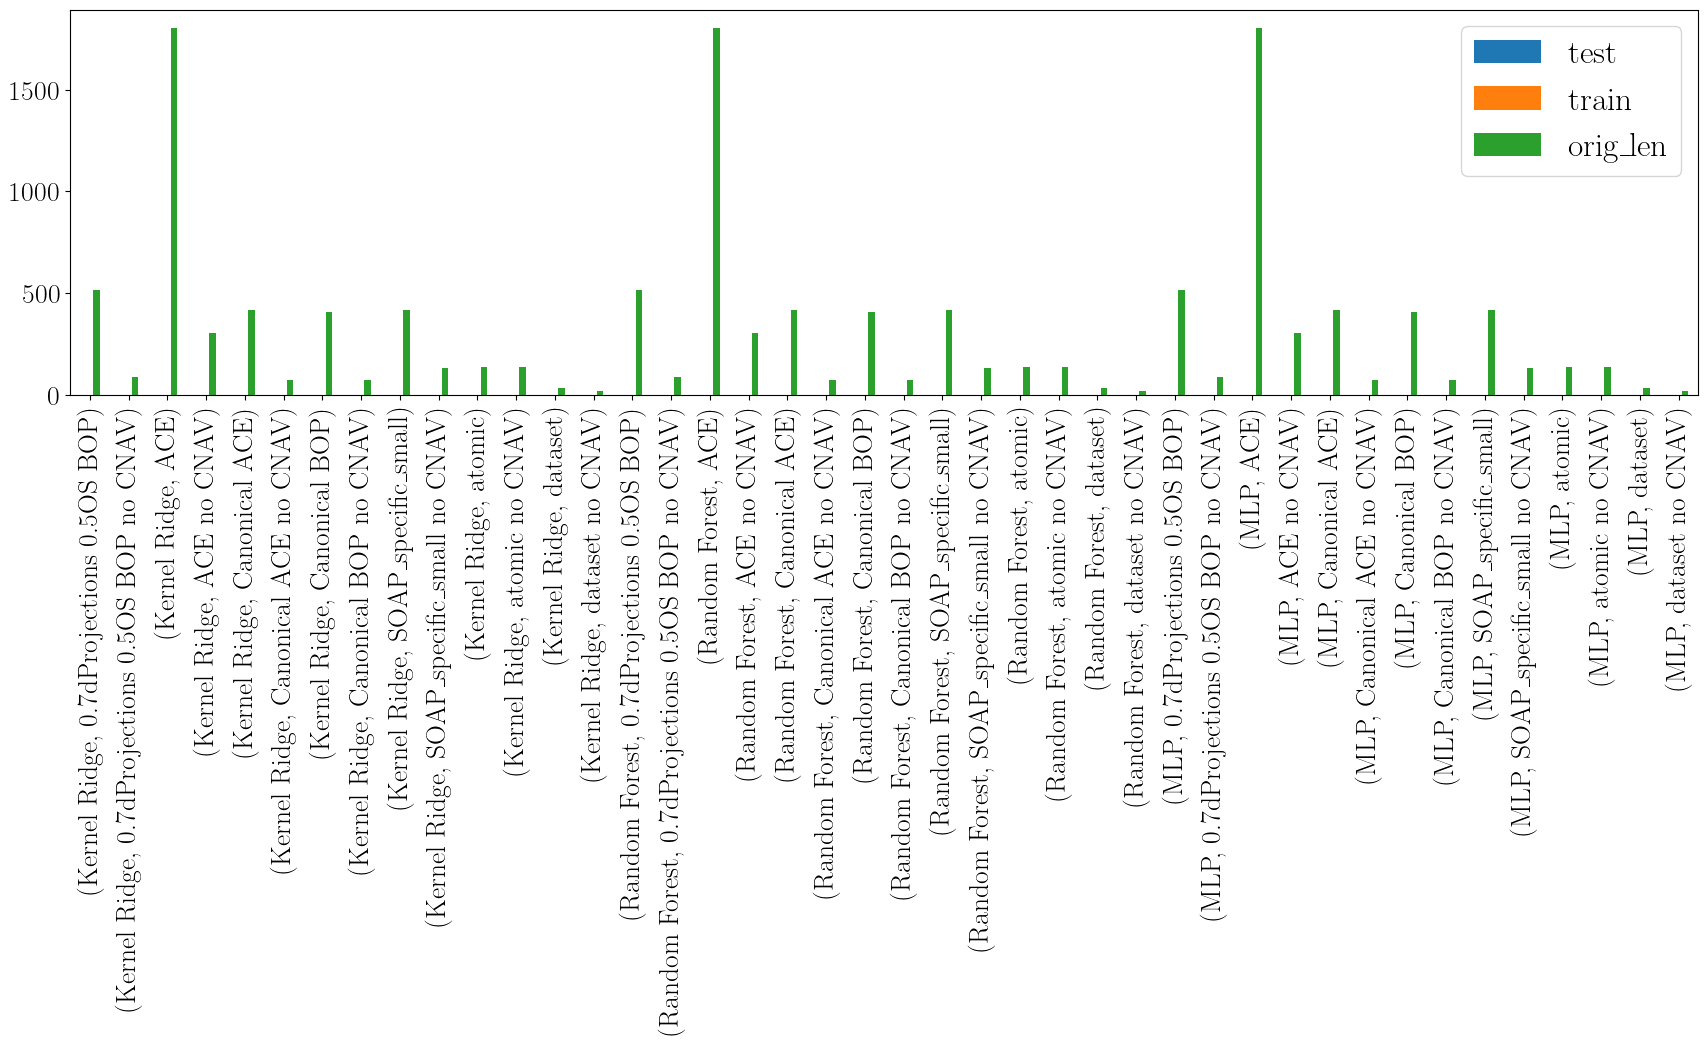

In [47]:
figwidth, figheight = plt.rcParams['figure.figsize']
OptimizedScoresDF.plot.bar(figsize=[3*figwidth, figheight])

In [48]:
unstack = OptimizedScoresDF.unstack(level=0)

In [49]:
iwanttoplot = unstack.index.difference(['SOAP', 'dataset + Projections BOP', 'Projections BOP', 'dataset + Projections sOS BOP', 'Projections OS BOP'])

In [50]:
iwanttoplot

Index(['0.7dProjections 0.5OS BOP', '0.7dProjections 0.5OS BOP no CNAV', 'ACE',
       'ACE no CNAV', 'Canonical ACE', 'Canonical ACE no CNAV',
       'Canonical BOP', 'Canonical BOP no CNAV', 'SOAP_specific_small',
       'SOAP_specific_small no CNAV', 'atomic', 'atomic no CNAV', 'dataset',
       'dataset no CNAV'],
      dtype='object')

In [51]:
test_scores = unstack['test'].loc[iwanttoplot].sort_values(by='Kernel Ridge', ascending=False)#.dropna(axis=0)

In [52]:
xs = {
    'ACE' : 7,
    'BOP': 5,
    'SOAP': 6,
    'sequential encoding': 4,
    'canonical BOP': 3,
    'Canonical ACE': 2,
    'Canonical SOAP': 1,
    'atomic': 0
}

In [53]:
deltas = {
    'Kernel Ridge': 0.25,
    'Random Forest': 0,
    'MLP': -0.25
}

In [54]:
clean_label_map = {
    '.*spProjections.*BOP': 'sp BOP',
    '.*dProjections.*BOP': 'BOP',
    'SOAP_specific_small': 'SOAP', 
    'SOAP_canonicalW_small': 'Canonical SOAP',
    'dataset' : 'sequential encoding',
    'Canonical BOP': 'canonical BOP'
}
def clean_label(label):
    cleanedlabel = copy.copy(label)
    for pattern, cleanlabel in clean_label_map.items():
        cleanedlabel = re.sub(pattern, cleanlabel, cleanedlabel)
    return cleanedlabel
    

In [55]:
colors = {'Kernel Ridge': 'brown',
         'Random Forest': 'steelblue', 
          'MLP': 'mediumseagreen'}

In [56]:
def assign_x(label, debug=False):
    if debug:
        print(label)
    if label not in xs.keys():
        return None
    return xs[label]

In [57]:
test_scores_cnav = test_scores[~test_scores.index.str.contains('no CNAV')].copy()
test_scores_cnav['labels'] = test_scores_cnav.index.map(clean_label)
test_scores_nocnav = test_scores[test_scores.index.str.contains('no CNAV')].copy()
test_scores_nocnav['labels'] = test_scores_nocnav.index.map(clean_label).str.replace(' no CNAV', '')
test_scores_cnav['xs'] = test_scores_cnav.labels.map(assign_x)
test_scores_nocnav['xs'] = test_scores_nocnav.labels.map(assign_x)


In [58]:
test_scores_cnav

,Kernel Ridge,MLP,Random Forest,labels,xs
atomic,0.167475,0.166495,0.155843,atomic,0
Canonical ACE,0.136919,0.139202,0.121238,Canonical ACE,2
Canonical BOP,0.107618,0.118236,0.107180,canonical BOP,3
dataset,0.053785,0.060482,0.052673,sequential encoding,4
SOAP_specific_small,0.049137,0.063279,0.082396,SOAP,6
0.7dProjections 0.5OS BOP,0.028210,0.040219,0.049695,BOP,5
ACE,0.026328,0.040443,0.050854,ACE,7


In [59]:
xticks = [value for key, value in xs.items() ]

In [60]:
xlabels = [key for key, value in xs.items()]

In [61]:
{key: 2*x for key, x in xs.items()}

{'ACE': 14,
 'BOP': 10,
 'SOAP': 12,
 'sequential encoding': 8,
 'canonical BOP': 6,
 'Canonical ACE': 4,
 'Canonical SOAP': 2,
 'atomic': 0}

In [62]:
{key: 2*d+0.25 for key, d in deltas.items()}

{'Kernel Ridge': 0.75, 'Random Forest': 0.25, 'MLP': -0.25}

In [63]:
{key: 2*d-0.25 for key, d in deltas.items()}

{'Kernel Ridge': 0.25, 'Random Forest': -0.25, 'MLP': -0.75}

In [64]:
renamed_test_scores_nocnav = test_scores_nocnav.copy()

In [65]:
renamed_test_scores_nocnav.index = renamed_test_scores_nocnav.index.str.replace(' no CNAV','')

In [89]:
ratios = {}
for model in ['Kernel Ridge', 'MLP', 'Random Forest']:
    ratios[model] = (test_scores_cnav[model]/renamed_test_scores_nocnav[model])[renamed_test_scores_nocnav.index]

In [90]:
from matplotlib.patches import FancyArrowPatch, FancyArrow
from matplotlib.lines import Line2D

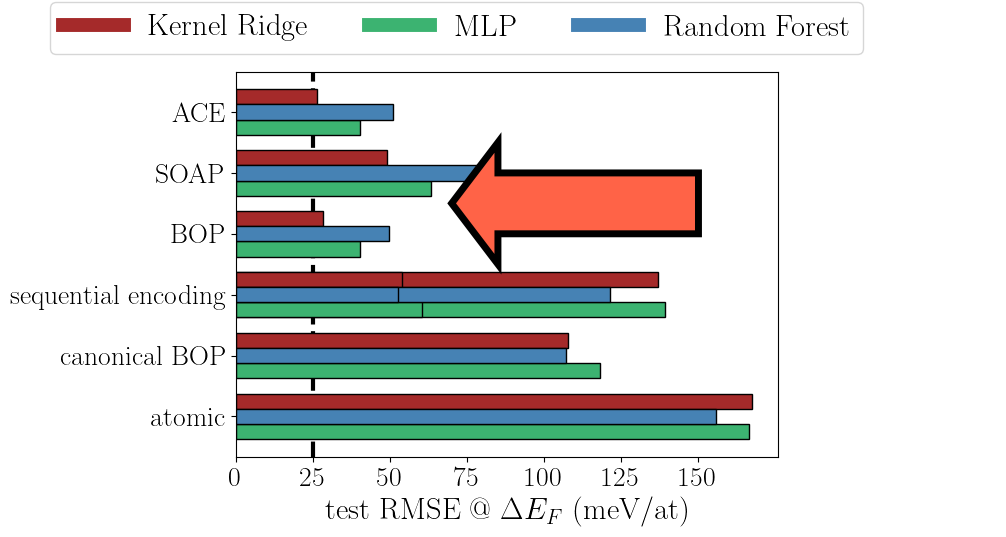

In [95]:
verts=[(-0.25,-2),(0.25,-2),(0.25,2),(-0.25,2),(-0.25,-2)]
codes = [Path.MOVETO, Path.LINETO, Path.LINETO, Path.LINETO, Path.CLOSEPOLY]
path = Path(verts, codes)
figwidth, figheight = plt.rcParams['figure.figsize']
fig, axs = plt.subplots(figsize=(figwidth,figheight))#, sharey=True)
m = 2
d = 0.25
w = d
handles = []
models = ['Kernel Ridge', 'MLP', 'Random Forest']
for model in models: #, 'Random Forest', 'MLP']:
    axs.barh(
        m*test_scores_cnav['xs'][ratios[model].index]+m*deltas[model],#+d, 
        test_scores_cnav[model][ratios[model].index].values*1000, m*w,
        color = colors[model],
        edgecolor='k', #colors[model],
    )
    handles.append(Line2D([],[],color=colors[model], linewidth=10))
#ax.set_xscale('log', subs=[8, 10, 15, 20,30, 40,50, 100])
axs.set_yticks([m*x for x in xticks])
axs.set_yticklabels(xlabels)
fig.legend(
    handles, models,
    ncol=len(models),
    loc=(0.05, 0.9),
    fontsize = 22
)
fancyarrow = FancyArrowPatch((130, 8),(40,10.7), mutation_scale=100, facecolor='tomato', linewidth=5)
fancyarrow = FancyArrow(150, 7,-80,0,width=2, head_length=15, head_width=4, length_includes_head=True, facecolor='tomato', linewidth=5)
axs.add_patch(fancyarrow)
axs.set_xticks([0,25,50,75,100,125,150])
#axs.text(60,10.75,'domain knowledge', fontsize=14)
axs.set_xlabel(r'test RMSE @ $\Delta E_F$ (meV/at)')
#fig.tight_layout()
axs.axvline(25, c='k', linestyle='--', zorder=0)
fig.savefig(os.path.join(dataset, 'graphs', f'{dataset}_CNAV_only.pdf'), bbox_inches='tight')

In [96]:
deltas

{'Kernel Ridge': 0.25, 'Random Forest': 0, 'MLP': -0.25}

In [97]:
selection = ~(test_scores_cnav.index.str.contains('SOAP_canonical') | test_scores_cnav.index.str.contains('Canonical ACE'))

In [98]:
test_scores_cnav['xs'][selection] = np.where(test_scores_cnav['xs'][selection] > 0,test_scores_cnav['xs'][selection] -2 , test_scores_cnav['xs'][selection])

/tmp/ipykernel_63471/903731865.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_scores_cnav['xs'][selection] = np.where(test_scores_cnav['xs'][selection] > 0,test_scores_cnav['xs'][selection] -2 , test_scores_cnav['xs'][selection])


In [99]:
test_scores_cnav[selection]

,Kernel Ridge,MLP,Random Forest,labels,xs
atomic,0.167475,0.166495,0.155843,atomic,0
Canonical BOP,0.107618,0.118236,0.107180,canonical BOP,-1
dataset,0.053785,0.060482,0.052673,sequential encoding,0
SOAP_specific_small,0.049137,0.063279,0.082396,SOAP,2
0.7dProjections 0.5OS BOP,0.028210,0.040219,0.049695,BOP,1
ACE,0.026328,0.040443,0.050854,ACE,3


In [100]:
xlabels = [key for key, value in xs.items() if 'Canonical ACE' not in key and 'Canonical SOAP' not in key]

In [101]:
xlabels

['ACE', 'BOP', 'SOAP', 'sequential encoding', 'canonical BOP', 'atomic']

In [102]:
selection

array([ True, False,  True,  True,  True,  True,  True])

In [103]:
xs = {key: value-2 if value > 2 else value for key, value in xs.items() if 'Canonical ACE' not in key and 'Canonical SOAP' not in key}

In [104]:
xs

{'ACE': 3,
 'BOP': 1,
 'SOAP': 2,
 'sequential encoding': 2,
 'canonical BOP': 1,
 'atomic': 0}

In [105]:
xticks = [value for key, value in xs.items()]

In [106]:
xticks

[3, 1, 2, 2, 1, 0]

In [107]:
xlabels

['ACE', 'BOP', 'SOAP', 'sequential encoding', 'canonical BOP', 'atomic']

In [108]:
deltas

{'Kernel Ridge': 0.25, 'Random Forest': 0, 'MLP': -0.25}

In [109]:
xlabels

['ACE', 'BOP', 'SOAP', 'sequential encoding', 'canonical BOP', 'atomic']

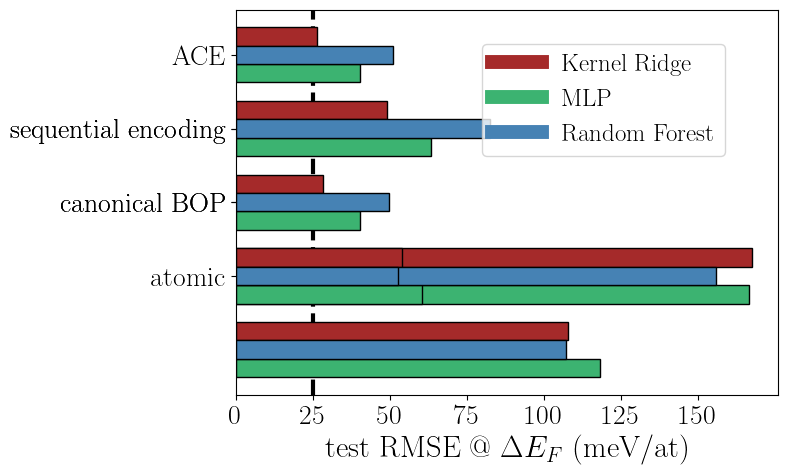

In [110]:
figwidth, figheight = plt.rcParams['figure.figsize']
fig, axs = plt.subplots(figsize=(figwidth,figheight), sharey=True)
plt.subplots_adjust(wspace=0.1)
m = 2
d = 0.25
w = d
handles = []
models = ['Kernel Ridge', 'MLP', 'Random Forest']
for model in models: #, 'Random Forest', 'MLP']:
    axs.barh(
        m*test_scores_cnav['xs'][selection]+m*deltas[model],#+d, 
        test_scores_cnav[model][selection].values*1000, m*w,
        color = colors[model],
        edgecolor='k', #colors[model],
    )
    handles.append(Line2D([],[],color=colors[model], linewidth=10))
#ax.set_xscale('log', subs=[8, 10, 15, 20,30, 40,50, 100])
axs.set_yticks([m*x for x in xticks])
axs.set_yticklabels(xlabels)
fig.legend(
    handles, models,
    ncol=1, #len(models),
    loc='center', #(0.75, 0.75),
    bbox_to_anchor=(0.65, 0.7),
    fontsize = 18
)
axs.set_xticks([0,25,50,75,100,125,150])
#axs.text(60,10.75,'domain knowledge', fontsize=14)
axs.set_xlabel(r'test RMSE @ $\Delta E_F$ (meV/at)')
#fig.tight_layout()
axs.axvline(25, c='k', linestyle='--', zorder=0)
fig.savefig(os.path.join(dataset, 'graphs', f'Figure_{dataset}_CNAV_only.pdf'), bbox_inches='tight')

In [111]:
ratios['Kernel Ridge'].drop(['atomic', 'Canonical ACE'], inplace=True)

In [116]:
ratios['Random Forest'].drop(['atomic', 'Canonical ACE'], inplace=True)

In [117]:
ratios['MLP'].drop( ['atomic', 'Canonical ACE'], inplace=True )


In [124]:
pd.concat(ratios, axis = 1)#['Kernel Ridge']

,Kernel Ridge,MLP,Random Forest
Canonical BOP,0.946355,0.926663,0.971391
dataset,0.510435,0.513947,0.512406
SOAP_specific_small,0.600803,0.988848,0.679813
0.7dProjections 0.5OS BOP,0.759366,0.719153,0.810149
ACE,0.999544,0.946080,0.820563


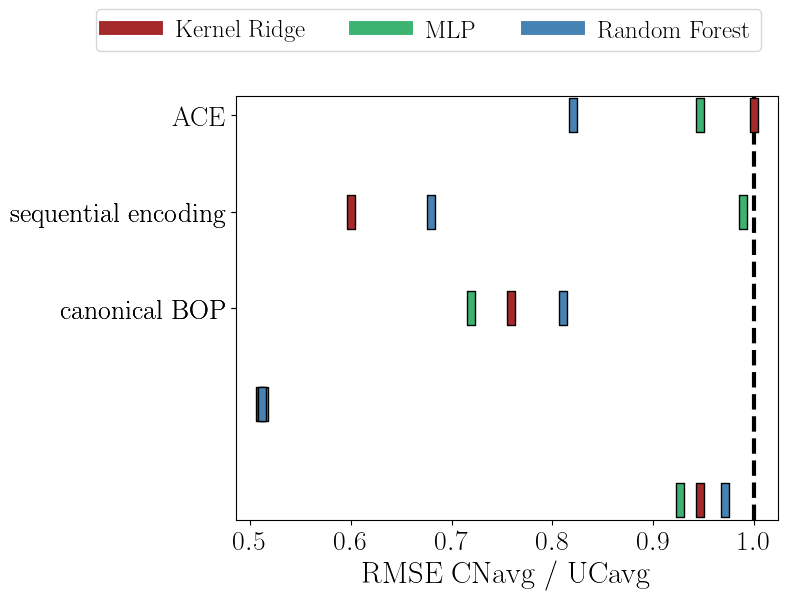

In [125]:
verts=[(-0.5,-2),(0.5,-2),(0.5,2),(-0.5,2),(-0.5,-2)]
codes = [Path.MOVETO, Path.LINETO, Path.LINETO, Path.LINETO, Path.CLOSEPOLY]
path = Path(verts, codes)
figwidth, figheight = plt.rcParams['figure.figsize']
fig, axs = plt.subplots(1,1, figsize=(figwidth,1.1*figheight), sharey=True)
plt.subplots_adjust(wspace=0.1)
m = 2
d = 0.25
w = d
handles = []
for model in ['Kernel Ridge', 'MLP', 'Random Forest']: #, 'Random Forest', 'MLP']:
    axs.scatter(
        ratios[model], #.drop('atomic'),#test_scores_cnav[model]/renamed_test_scores_nocnav[model], 
        m*test_scores_cnav['xs'][ratios[model].index], #.drop('atomic').index], 
        color = colors[model],
        marker=path,
        s=600,
        edgecolor='k', #colors[model],
    )
    handles.append(Line2D([],[],color=colors[model], linewidth=10))
axs.set_xlabel(r'RMSE CNavg / UCavg')
axs.set_yticks([m*x for x in xticks[:-1]])
axs.set_yticklabels(xlabels[:-1])
fig.legend(
    handles,
    models, #+['no CNAV'],
    ncol=len(models),
    loc='center',
    bbox_to_anchor=(0.4, 1),
    fontsize = 18

)
axs.axvline(1, c='k', linestyle='--', zorder=0)
fig.savefig(os.path.join(dataset, 'graphs', f'Figure_{dataset}_CNAV_vs_noCNAV.pdf'), bbox_inches='tight')

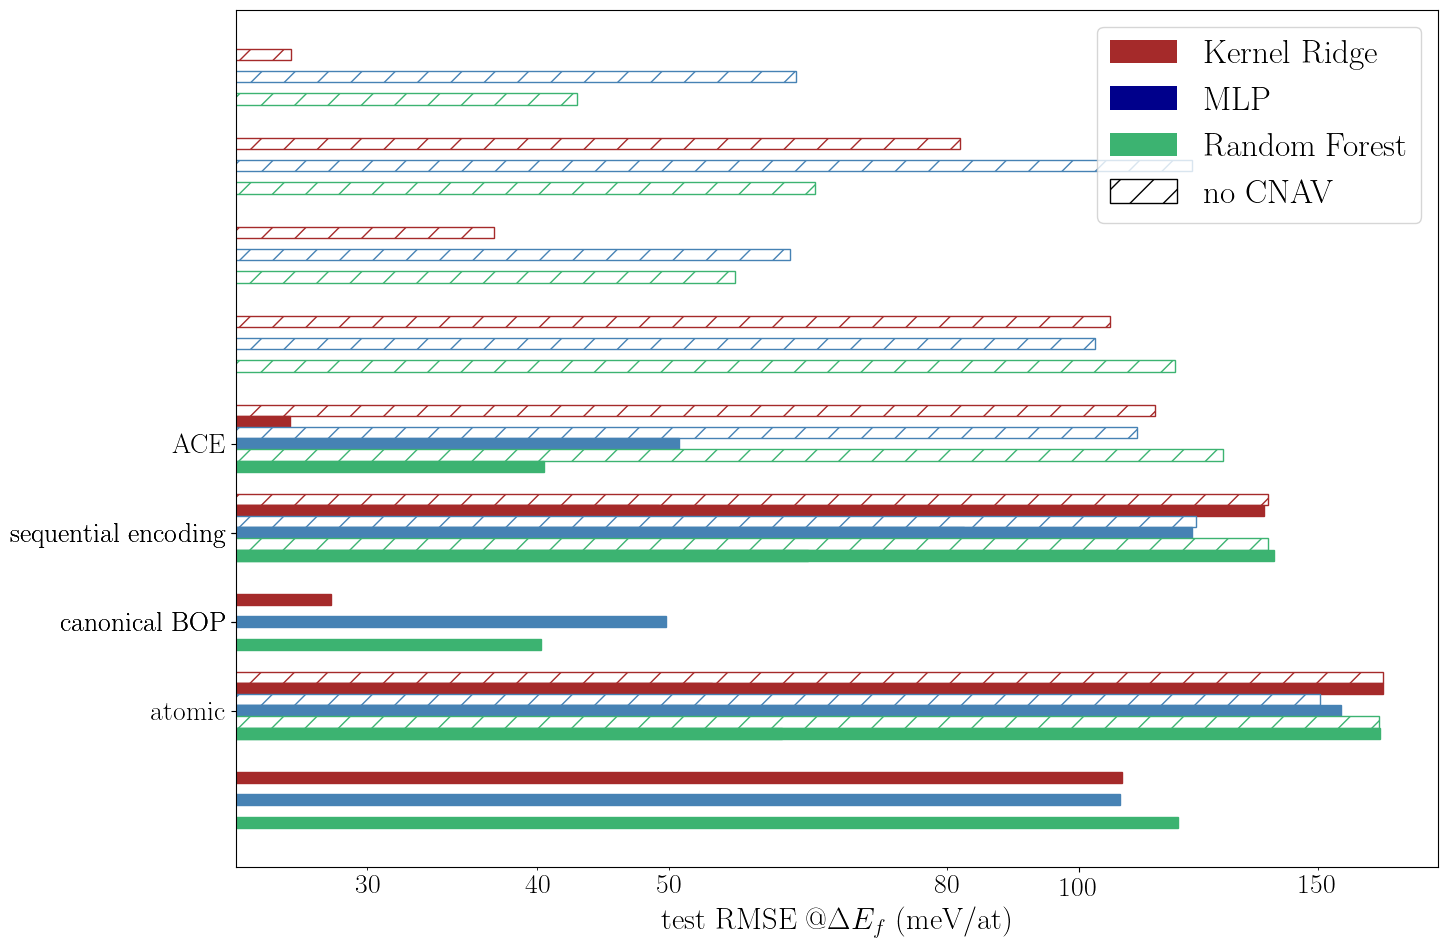

In [126]:
fig, ax = plt.subplots(figsize=(15,10))
m = 2
d = 0.25
w = d
for model in ['Kernel Ridge', 'Random Forest', 'MLP']:
    ax.barh(
        m*test_scores_nocnav['xs'].values+m*deltas[model]+d,
        test_scores_nocnav[model].values*1000, w,
        color = colors[model],
        facecolor=(1,1,1,1),
        hatch = '/',
#        linewidth = 5
    )
    ax.barh(
        m*test_scores_nocnav['xs'].values+m*deltas[model]+d,
        test_scores_nocnav[model].values*1000, w,
        color = colors[model],
        facecolor=(1,1,1,1),
        hatch = '/',
        edgecolor=colors[model],
#        linewidth=5
    )
    ax.barh(
        m*test_scores_cnav['xs'].values+m*deltas[model],
        test_scores_cnav[model].values*1000, w,
        color = colors[model],
        edgecolor=colors[model],
#        linewidth=5,
#        zorder = 1
    )
ax.set_xscale('log', subs=[8, 10, 15, 20,30, 40,50, 100])
ax.tick_params(axis='x', which='minor')
ax.xaxis.set_minor_formatter(FormatStrFormatter("%.0f"))
ax.tick_params(axis='x', which='major')
ax.xaxis.set_major_formatter(FormatStrFormatter("%.0f"))
ax.set_xlabel(r'test RMSE @$\Delta E_f$ (meV/at)')
ax.set_yticks([m*x for x in xticks])
ax.set_yticklabels(xlabels)
plt.legend(
    [Patch(facecolor='brown'),
     Patch(facecolor='darkblue'),
     Patch(facecolor='mediumseagreen'), 
     Patch(facecolor=(1,1,1,0.5), hatch='/', ec='black')
    ],
    models+['no CNAV'],
    ncol=1,
)
fig.tight_layout()
fig.savefig(os.path.join(dataset, 'graphs', f'{dataset}_OptimalRegresorComparison.pdf'))